In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold

In [2]:
no_dummies = pd.read_csv('Step 4 - Final Dataset without dummies.csv')

In [3]:
scout_car = pd.read_csv('Step 4 - Final Dataset with dummies.csv')
scout_car

,Price,KM,Registration,Horsepower (kW),Previous Owners,Inspection new,Warranty (months),# of Doors,# of Seats,Displacement (cc),...,Country version_Poland,Country version_Spain,Upholstery Material_Full leather,Upholstery Material_Other,Upholstery Material_Part leather,Upholstery Material_Velour,Upholstery Material_alcantara,Upholstery Color_Brown,Upholstery Color_Grey,Upholstery Color_Other
0,15770.0,56013.0,2016.0,66.0,2,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
1,14500.0,80000.0,2017.0,141.0,0,0,0.0,3.0,4.0,1798.0,...,0,0,0,0,0,0,0,0,1,0
2,14640.0,83450.0,2016.0,85.0,1,0,0.0,5.0,4.0,1598.0,...,0,0,0,0,0,0,0,0,0,0
3,14500.0,73000.0,2016.0,66.0,1,0,0.0,3.0,4.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
4,16790.0,16200.0,2016.0,66.0,1,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15095,39950.0,10.0,2016.0,147.0,0,0,0.0,5.0,5.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15096,39885.0,9900.0,2019.0,165.0,1,0,0.0,5.0,5.0,1798.0,...,0,0,0,0,0,0,0,0,0,0
15097,39875.0,15.0,2019.0,146.0,1,1,0.0,5.0,7.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15098,39700.0,10.0,2019.0,147.0,0,0,0.0,5.0,7.0,1997.0,...,0,0,0,0,1,0,0,0,0,0


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from scipy import stats

# Features
X = scout_car.drop(columns=['Price'])

# Target
y = scout_car['Price']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)

RandomForestRegressor()

In [5]:
y_pred = rfr.predict(X_test)
y_pred

array([34677.98, 11136.53, 38361.12, ..., 11070.08,  7320.17, 20187.81])

In [6]:
# Create a new DataFrame showing the samples indices next to the non-dummy columns.
# This will allow us to compare results side-by-side with these categorial columns.
samples_no_dummies = no_dummies.loc[X_test.index]

# Build a new DataFrame compiling the results of the Linear Regression for each sample.
# We can also load categorical columns into this DataFrame.
rfr_init_results = pd.DataFrame()
rfr_init_results['make_model'] = samples_no_dummies['make_model']
rfr_init_results['Actual Price'] = y_test
rfr_init_results['Predicted Price'] = np.round(y_pred).astype(int)
rfr_init_results['Error'] = rfr_init_results['Predicted Price'] - rfr_init_results['Actual Price']
rfr_init_results['Squared Error'] = rfr_init_results['Error'] ** 2
rfr_init_results['Absolute Error'] = rfr_init_results['Error'].abs()
rfr_init_results

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
14845,Renault Espace,34985.0,34678,-307.0,94249.0,307.0
14120,Renault Clio,11280.0,11137,-143.0,20449.0,143.0
14860,Renault Espace,38875.0,38361,-514.0,264196.0,514.0
884,Audi A1,14500.0,15512,1012.0,1024144.0,1012.0
411,Audi A1,15900.0,17201,1301.0,1692601.0,1301.0
...,...,...,...,...,...,...
499,Audi A1,13700.0,13333,-367.0,134689.0,367.0
668,Audi A1,12451.0,12684,233.0,54289.0,233.0
8028,Opel Corsa,12990.0,11070,-1920.0,3686400.0,1920.0
8495,Opel Corsa,7650.0,7320,-330.0,108900.0,330.0


In [7]:
print(f"Mean squared error: {rfr_init_results['Squared Error'].mean()}")
print(f"Mean absolute error: {rfr_init_results['Absolute Error'].mean()}")
print(f"Median absolute error: {rfr_init_results['Absolute Error'].median()}")

Mean squared error: 2404902.075165563
Mean absolute error: 916.9950331125827
Median absolute error: 527.5


In [8]:
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"Median Absolute Error: {median_absolute_error(y_test, y_pred)}")

R2 Score: 0.9575034104642804
Mean Squared Error: 2404920.218878295
Mean Absolute Error: 916.999803380431
Median Absolute Error: 527.4749999999985


In [9]:
rfr_init_results.nsmallest(10, 'Absolute Error')

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
351,Audi A1,14990.0,14990,0.0,0.0,0.0
14943,Renault Espace,34200.0,34200,0.0,0.0,0.0
2380,Audi A1,28820.0,28820,0.0,0.0,0.0
339,Audi A1,14990.0,14990,0.0,0.0,0.0
290,Audi A1,15090.0,15090,0.0,0.0,0.0
12794,Renault Clio,8490.0,8490,0.0,0.0,0.0
286,Audi A1,15090.0,15090,0.0,0.0,0.0
9791,Opel Corsa,10979.0,10979,0.0,0.0,0.0
9422,Opel Corsa,9800.0,9800,0.0,0.0,0.0
1213,Audi A1,15850.0,15850,0.0,0.0,0.0


In [10]:
(rfr_init_results[rfr_init_results['Absolute Error'] == 0]).count()

make_model         79
Actual Price       79
Predicted Price    79
Error              79
Squared Error      79
Absolute Error     79
dtype: int64

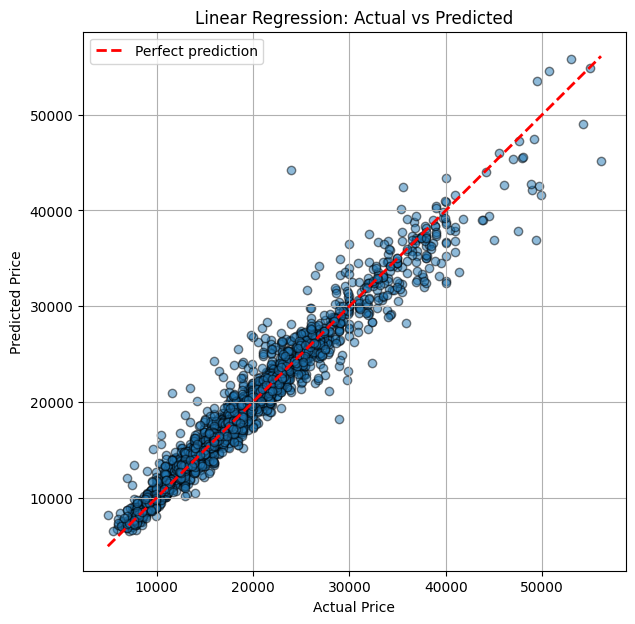

In [11]:
# Predictions on the test set
y_pred = rfr.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='black', linewidths=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', linewidth=2, label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

# RFR with K Fold

In [12]:
# Define K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation using R² score
cv_scores = cross_val_score(rfr, X, y, cv=kf, scoring='r2')

print("Cross-validation R² scores:", cv_scores)
print("Mean R²:", np.mean(cv_scores))
print("Standard deviation of R²:", np.std(cv_scores))

Cross-validation R² scores: [0.95853205 0.95086042 0.95233861 0.95263275 0.952084  ]
Mean R²: 0.9532895648052241
Standard deviation of R²: 0.002689740652526737


In [13]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold predictions for all data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_all = cross_val_predict(rfr, X, y, cv=kf)

# Build results dataframe
rfr_cv_results = pd.DataFrame()
rfr_cv_results['make_model'] = no_dummies['make_model']
rfr_cv_results['Actual Price'] = y
rfr_cv_results['Predicted Price'] = np.round(y_pred_all).astype(int)
rfr_cv_results['Error'] = rfr_cv_results['Predicted Price'] - rfr_cv_results['Actual Price']
rfr_cv_results['Squared Error'] = rfr_cv_results['Error'] ** 2
rfr_cv_results['Absolute Error'] = rfr_cv_results['Error'].abs()
rfr_cv_results

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
0,Audi A1,15770.0,16220,450.0,202500.0,450.0
1,Audi A1,14500.0,14660,160.0,25600.0,160.0
2,Audi A1,14640.0,14593,-47.0,2209.0,47.0
3,Audi A1,14500.0,14612,112.0,12544.0,112.0
4,Audi A1,16790.0,17220,430.0,184900.0,430.0
...,...,...,...,...,...,...
15095,Renault Espace,39950.0,40155,205.0,42025.0,205.0
15096,Renault Espace,39885.0,37518,-2367.0,5602689.0,2367.0
15097,Renault Espace,39875.0,38873,-1002.0,1004004.0,1002.0
15098,Renault Espace,39700.0,39632,-68.0,4624.0,68.0


In [14]:
(rfr_cv_results[rfr_cv_results['Absolute Error'] == 0])['Absolute Error'].count()

np.int64(463)

486 cars out of 15100 were predicted perfectly.

In [16]:
rfr_cv_results.to_csv('/Users/matthewcavanaugh/Desktop/GitHub/magnimind/Auto Scout Project/Model Results/RESULTS RFR no GS')

# RFR with GridSearchCV